<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2Fcustomcnn/notebooks/01_Custom_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Classification Using MRI Images
## Custom CNN — Member 1

This notebook implements a Custom Convolutional Neural Network (CNN)
from scratch for four-class brain tumor classification.

Classes:
1. Glioma
2. Meningioma
3. No Tumor
4. Pituitary

The model uses the common train, validation, and test splits prepared
for the group project.


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_path = "/content/drive/MyDrive/SE4050_DL_Assignment/Dataset"

print(os.listdir(project_path))

['dataset_config.py', 'dataset']


## Project Paths

The dataset is stored in Google Drive. The CSV files contain relative
paths such as `Training/glioma/Tr-gl_365.jpg`, so the dataset root is
used as the base path for locating the MRI images.

In [4]:
import os

# Root folder containing Training, Testing and splits
DATASET_ROOT = "/content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset"

# Split CSV directory
SPLIT_DIR = os.path.join(DATASET_ROOT, "splits")

# Image directories
TRAIN_IMAGE_DIR = os.path.join(DATASET_ROOT, "Training")
TEST_IMAGE_DIR = os.path.join(DATASET_ROOT, "Testing")

print("Dataset root:", DATASET_ROOT)
print("Split directory:", SPLIT_DIR)
print("Training directory:", TRAIN_IMAGE_DIR)
print("Testing directory:", TEST_IMAGE_DIR)

Dataset root: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset
Split directory: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/splits
Training directory: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/Training
Testing directory: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/Testing


In [5]:
print("\nDataset contents:")
print(os.listdir(DATASET_ROOT))

print("\nTraining classes:")
print(os.listdir(TRAIN_IMAGE_DIR))

print("\nTesting classes:")
print(os.listdir(TEST_IMAGE_DIR))

print("\nSplit files:")
print(os.listdir(SPLIT_DIR))


Dataset contents:
['Training', 'Testing', 'splits']

Training classes:
['glioma', 'pituitary', 'meningioma', 'notumor']

Testing classes:
['glioma', 'pituitary', 'meningioma', 'notumor']

Split files:
['train.csv', 'val.csv', 'test.csv', 'test.gsheet', 'train.gsheet']


## Load Common Dataset Splits

The group uses a fixed dataset split so that all four models are trained
and evaluated using the same images.

- Training: 4,480 images
- Validation: 1,120 images
- Testing: 1,600 images
- Random seed: 42

In [6]:
import pandas as pd

train_csv = os.path.join(SPLIT_DIR, "train.csv")
val_csv = os.path.join(SPLIT_DIR, "val.csv")
test_csv = os.path.join(SPLIT_DIR, "test.csv")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4480
Validation: 1120
Test: 1600


In [7]:
# Check the CSV contents
train_df.head()

,filepath,label,class_name
0,Training/pituitary/Tr-pi_135.jpg,3,Pituitary
1,Training/notumor/Tr-no_154.jpg,2,No Tumor
2,Training/glioma/Tr-gl_365.jpg,0,Glioma
3,Training/pituitary/Tr-pi_125.jpg,3,Pituitary
4,Training/glioma/Tr-gl_433.jpg,0,Glioma


In [8]:
print("Train columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['filepath', 'label', 'class_name']
Validation columns: ['filepath', 'label', 'class_name']
Test columns: ['filepath', 'label', 'class_name']


In [9]:
# Verify class distributions
print("Training distribution:")
print(train_df["class_name"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["class_name"].value_counts().sort_index())

Training distribution:
class_name
Glioma        1120
Meningioma    1120
No Tumor      1120
Pituitary     1120
Name: count, dtype: int64

Validation distribution:
class_name
Glioma        280
Meningioma    280
No Tumor      280
Pituitary     280
Name: count, dtype: int64

Test distribution:
class_name
Glioma        400
Meningioma    400
No Tumor      400
Pituitary     400
Name: count, dtype: int64


In [10]:
# Verify an actual image
sample_relative_path = train_df.iloc[0]["filepath"]

sample_image_path = os.path.join(
    DATASET_ROOT,
    sample_relative_path
)

print("Relative path:", sample_relative_path)
print("Full path:", sample_image_path)
print("File exists:", os.path.exists(sample_image_path))

Relative path: Training/pituitary/Tr-pi_135.jpg
Full path: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/Training/pituitary/Tr-pi_135.jpg
File exists: True


Image size: (512, 512)
Image mode: RGB


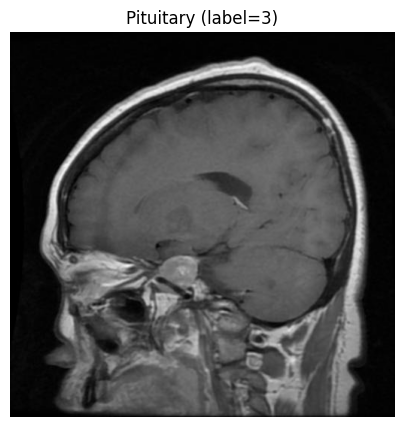

In [11]:
# Display one MRI image
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open(sample_image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title(
    f"{train_df.iloc[0]['class_name']} "
    f"(label={train_df.iloc[0]['label']})"
)
plt.axis("off")
plt.show()

## Reproducibility and Preprocessing Configuration

The project uses a fixed random seed of 42 to improve reproducibility.

Images are resized to 224 × 224 pixels and pixel values are normalized
to the range [0, 1]. A batch size of 16 is used according to the common
group configuration.

In [29]:
# Reproducibility and project configuration

import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset configuration
CLASS_NAMES = {
    0: "Glioma",
    1: "Meningioma",
    2: "No Tumor",
    3: "Pituitary"
}

NUM_CLASSES = 4

# Image and training configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10

print("Random seed:", SEED)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Random seed: 42
Image size: (224, 224)
Batch size: 16
Number of classes: 4
Classes: {0: 'Glioma', 1: 'Meningioma', 2: 'No Tumor', 3: 'Pituitary'}


In [13]:
# Create the image path columns
train_df["full_path"] = train_df["filepath"].apply(
    lambda x: os.path.join(DATASET_ROOT, x)
)

val_df["full_path"] = val_df["filepath"].apply(
    lambda x: os.path.join(DATASET_ROOT, x)
)

test_df["full_path"] = test_df["filepath"].apply(
    lambda x: os.path.join(DATASET_ROOT, x)
)

In [14]:
train_df[["filepath", "full_path", "label", "class_name"]].head()

,filepath,full_path,label,class_name
0,Training/pituitary/Tr-pi_135.jpg,/content/drive/MyDrive/SE4050_DL_Assignment/Da...,3,Pituitary
1,Training/notumor/Tr-no_154.jpg,/content/drive/MyDrive/SE4050_DL_Assignment/Da...,2,No Tumor
2,Training/glioma/Tr-gl_365.jpg,/content/drive/MyDrive/SE4050_DL_Assignment/Da...,0,Glioma
3,Training/pituitary/Tr-pi_125.jpg,/content/drive/MyDrive/SE4050_DL_Assignment/Da...,3,Pituitary
4,Training/glioma/Tr-gl_433.jpg,/content/drive/MyDrive/SE4050_DL_Assignment/Da...,0,Glioma


In [22]:
# Build the TensorFlow data pipeline
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [23]:
# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["full_path"].values, train_df["label"].values)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_df["full_path"].values, val_df["label"].values)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df["full_path"].values, test_df["label"].values)
)

In [24]:
train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=SEED,
    reshuffle_each_iteration=True
)

In [25]:
# Apply preprocessing
train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [26]:
# Batch and optimize
train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [27]:
# Test the Pipeline
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Pixel minimum: 0.0
Pixel maximum: 1.0


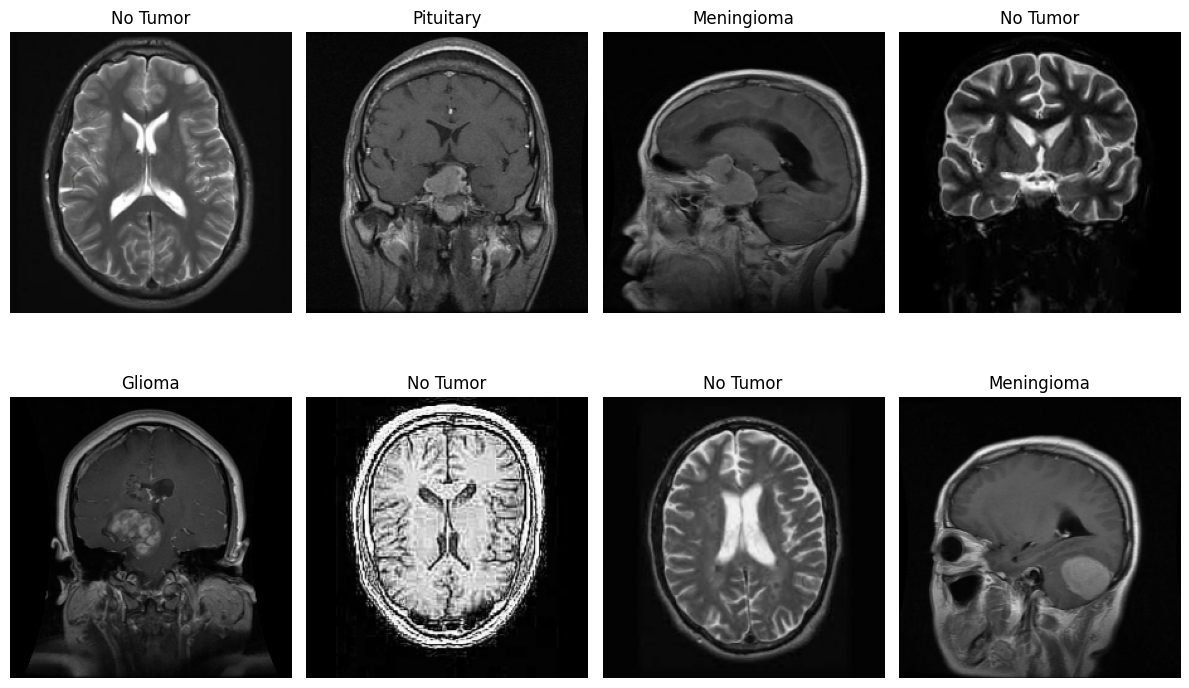

In [30]:
# Visualize a batch
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(CLASS_NAMES[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Build the Custom CNN

In [31]:
# Create the model
from tensorflow.keras import layers, models

custom_cnn = models.Sequential([
    # Input
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(NUM_CLASSES, activation="softmax")
])

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [33]:
# Train the Custom CNN
import time

start_time = time.time()

history = custom_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 198s 683ms/step - accuracy: 0.7080 - loss: 0.7165 - val_accuracy: 0.8545 - val_loss: 0.4105
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.8451 - loss: 0.4130 - val_accuracy: 0.8179 - val_loss: 0.4888
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.8906 - loss: 0.2931 - val_accuracy: 0.9107 - val_loss: 0.2474
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.9297 - loss: 0.1961 - val_accuracy: 0.9241 - val_loss: 0.2222
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9451 - loss: 0.1426 - val_accuracy: 0.9366 - val_loss: 0.2048
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9616 - loss: 0.1014 - val_accuracy: 0.9429 - val_loss: 0.1989
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.9725 - loss: 0.0755 - val_accuracy: 0.9473 - val_loss: 0.2052
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.9795 - loss: 0.0516 

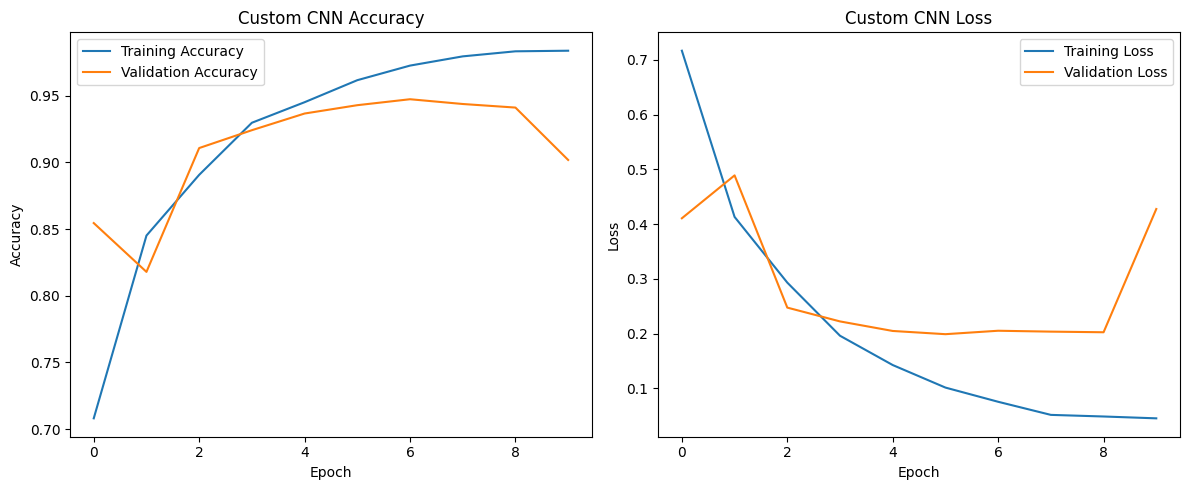

In [34]:
# Plot the training curves
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")
plt.legend()

plt.tight_layout()
plt.show()